# Apple Stock Price Prediction – Exploratory Data Analysis

**Project ID:** P668  
**Objective:** Develop a predictive model to forecast Apple stock prices for the next 30 days
using historical data (2012–2019), enabling investors and analysts to make informed decisions.  
**Dataset:** `P668 DATASET.csv` renamed to `dataset.csv`.                              
**Time Period:** January 2012 – December 2019

---
## Step 1: Load & Explore Data

---

We begin by importing all the essential Python libraries for data loading,
manipulation, statistical analysis, and visualization.

| Library | Purpose |
|---------|----------|
| `pandas` | Data loading, manipulation, tabular operations |
| `numpy` | Numerical computations and array operations |
| `matplotlib` | Low-level plotting and charting |
| `seaborn` | High-level statistical visualizations |
| `statsmodels` | Stationarity tests (ADF Test, ACF, PACF) |
| `scipy` | Statistical functions (Z-score outlier detection) |


In [30]:
# ── Core Libraries 
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualization Libraries 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Statistical Libraries 
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Display Settings 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', 15)

print('All libraries imported successfully!')


All libraries imported successfully!


### 1a. Dataset Loading & Initial Inspection

### Dataset Description

The dataset contains **daily historical stock price data for Apple Inc. (AAPL)** from 2012 to 2019.

| Column | Description |
|--------|-------------|
| `Date` | Trading date |
| `Open` | Opening stock price |
| `High` | Highest price during the trading day |
| `Low` | Lowest price during the trading day |
| `Close` | Closing stock price |
| `Adj Close` | Adjusted closing price (accounts for dividends & splits) |
| `Volume` | Number of shares traded |

**Target Variable:** Forecasted closing price 30 days into the future


In [31]:
# Load the Apple stock price dataset
df_raw = pd.read_csv('dataset.csv')

print(f'Dataset loaded successfully!')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print()
df_raw.head()


Dataset loaded successfully!
Shape: 2011 rows x 7 columns



,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.4857,58.9286,58.4286,58.7471,50.7657,75555200
1,2012-01-04,58.5714,59.2400,58.4686,59.0629,51.0385,65005500
2,2012-01-05,59.2786,59.7929,58.9529,59.7186,51.6052,67817400
3,2012-01-06,59.9671,60.3929,59.8886,60.3429,52.1446,79573200
4,2012-01-09,60.7857,61.1071,60.1929,60.2471,52.0619,98506100



We examine:
- **Shape** – Number of rows and columns
- **Data Types** – Numeric vs. categorical columns
- **Non-null Counts** – Indicator of missing data

In [32]:
# Dataset structure
print('=' * 55)
print('         DATASET STRUCTURE & INFORMATION')
print('=' * 55)
df_raw.info()


         DATASET STRUCTURE & INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   str    
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 129.7 KB


---
## Step 2: Data Cleaning & Preparation
---

For time-series analysis, we must:

1. **Convert the `Date` column** from `object` dtype to `datetime` format
2. **Set `Date` as the index** – Required for time-series operations
3. **Sort chronologically** – Ensures temporal order is preserved

> Proper date indexing is essential for rolling statistics, resampling, and stationarity tests.

In [33]:
# Work on a clean copy
df = df_raw.copy()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as the index
df.set_index('Date', inplace=True)

# Sort by date (chronological order)
df = df.sort_index()

print('Data cleaning complete!')
print(f'Date Range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Total Trading Days: {len(df)}')
print()
df.head()


Data cleaning complete!
Date Range: 2012-01-03 to 2019-12-30
Total Trading Days: 2011



,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.4857,58.9286,58.4286,58.7471,50.7657,75555200
2012-01-04,58.5714,59.2400,58.4686,59.0629,51.0385,65005500
2012-01-05,59.2786,59.7929,58.9529,59.7186,51.6052,67817400
2012-01-06,59.9671,60.3929,59.8886,60.3429,52.1446,79573200
2012-01-09,60.7857,61.1071,60.1929,60.2471,52.0619,98506100


### 2a. Missing Values Analysis

Missing values in time-series stock data can occur due to:
- **Market holidays** (usually excluded from the dataset)
- **Data collection errors**
- **Exchange outages**

We check for missing values both numerically and visually.

In [34]:
# Missing Values Summary
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('=' * 40)
print('      MISSING VALUES REPORT')
print('=' * 40)
print(missing_df.to_string())
print('=' * 40)

if missing.sum() == 0:
    print('\nNo missing values found! Dataset is complete.')
else:
    print(f'\nTotal missing values: {missing.sum()}')


      MISSING VALUES REPORT
           Missing Count  Missing %
Open                   0     0.0000
High                   0     0.0000
Low                    0     0.0000
Close                  0     0.0000
Adj Close              0     0.0000
Volume                 0     0.0000

No missing values found! Dataset is complete.


**Observation**

**There are zero missing values across all columns.**  
The dataset is complete and no imputation is required.

> *"The dataset consists of 2,011 daily observations with no gaps — providing an
uninterrupted, high-quality time series for reliable forecasting."*


### 2b. Duplicate Records Check

In stock data, each date should appear exactly **once**.
Multiple rows for the same trading day indicate a data collection error.


In [35]:
# Duplicate Check
duplicates = df.index.duplicated().sum()

print(f'Total Duplicate Date Entries: {duplicates}')

if duplicates == 0:
    print('No duplicate records found! Each trading day appears exactly once.')
else:
    print(f'Found {duplicates} duplicate date entries. Dropping duplicates...')
    df = df[~df.index.duplicated(keep='first')]
    print(f'Duplicates removed. New shape: {df.shape}')


Total Duplicate Date Entries: 0
No duplicate records found! Each trading day appears exactly once.


### 2c. Descriptive Statistics

Descriptive statistics provide a **high-level numerical summary** helping us understand:

- **Central Tendency** – Where the data is centered (mean, median)
- **Spread** – How dispersed the data is (std, min, max, IQR)
- **Skewness** – Asymmetry in the distribution
- **Kurtosis** – how heavy the tails (outliers) of a distribution are compared to normal distribution.

In [36]:
# Standard Descriptive Statistics
print('=' * 70)
print('              DESCRIPTIVE STATISTICS SUMMARY')
print('=' * 70)
# df.describe().T 

extended_stats = pd.DataFrame({
    'Mean':     df.mean(),
    'Median':   df.median(),
    'Std Dev':  df.std(),
    'Min':      df.min(),
    'Max':      df.max(),
    'IQR':      df.quantile(0.75) - df.quantile(0.25),
    'Skewness': df.skew(),
    'Kurtosis': df.kurtosis()
})

print('Extended Statistics:')
extended_stats.round(4)


              DESCRIPTIVE STATISTICS SUMMARY
Extended Statistics:


,Mean,Median,Std Dev,Min,Max,IQR,Skewness,Kurtosis
Open,126.7075,113.0500,50.4838,55.4243,291.1200,79.3071,0.7694,-0.1721
High,127.8276,114.1900,50.9263,57.0857,293.9700,80.6921,0.7709,-0.1745
Low,125.5803,111.8700,50.1249,55.0143,288.1200,78.3686,0.7709,-0.1616
Close,126.7412,113.0500,50.5784,55.7900,291.5200,79.0429,0.7738,-0.1550
Adj Close,119.5055,105.2229,52.4384,48.9219,289.5226,84.9904,0.7941,-0.1653
Volume,59496704.7240,43469000.0000,46838558.4855,11362000.0000,376530000.0000,47124650.0000,2.1650,6.3222


### Key Observations from Descriptive Statistics

| Metric | Finding | Interpretation |
|--------|---------|----------------|
| **Dataset Size** | 2,011 trading days | Robust time-series base for reliable forecasting |
| **Mean Close** | ~$126.74 | Average stock price across the period |
| **Median Close** | ~$113.05 | Median < Mean → Right-skewed distribution |
| **Min Close** | ~$55.79 | Stock price at the beginning of the period |
| **Max Close** | ~$291.52 | Stock price near end of the period |
| **Std Dev (Close)** | ~$50.58 | High volatility reflecting market fluctuations |
| **IQR (Close)** | ~$79.04 | Wide spread: Q1 ≈ $86.20, Q3 ≈ $165.25 |
| **Positive Skewness** | > 0 | More lower-priced days; upper tail pulled by price surge |
| **Volume Max** | ~376M shares | Huge spikes indicate major market events |

> *"The data demonstrates significant long-term growth in Apple's stock price,
with high standard deviation confirming substantial price volatility.
The right-skewed distribution reflects the accelerating growth in later years."*


---
## Step 3: Univariate Analysis
---

Univariate analysis explores **one variable at a time**. For stock data, we examine:
- **Histograms** – Distribution shape (normal, skewed, bimodal)
- **Box Plots** – Spread, median, and outliers at a glance


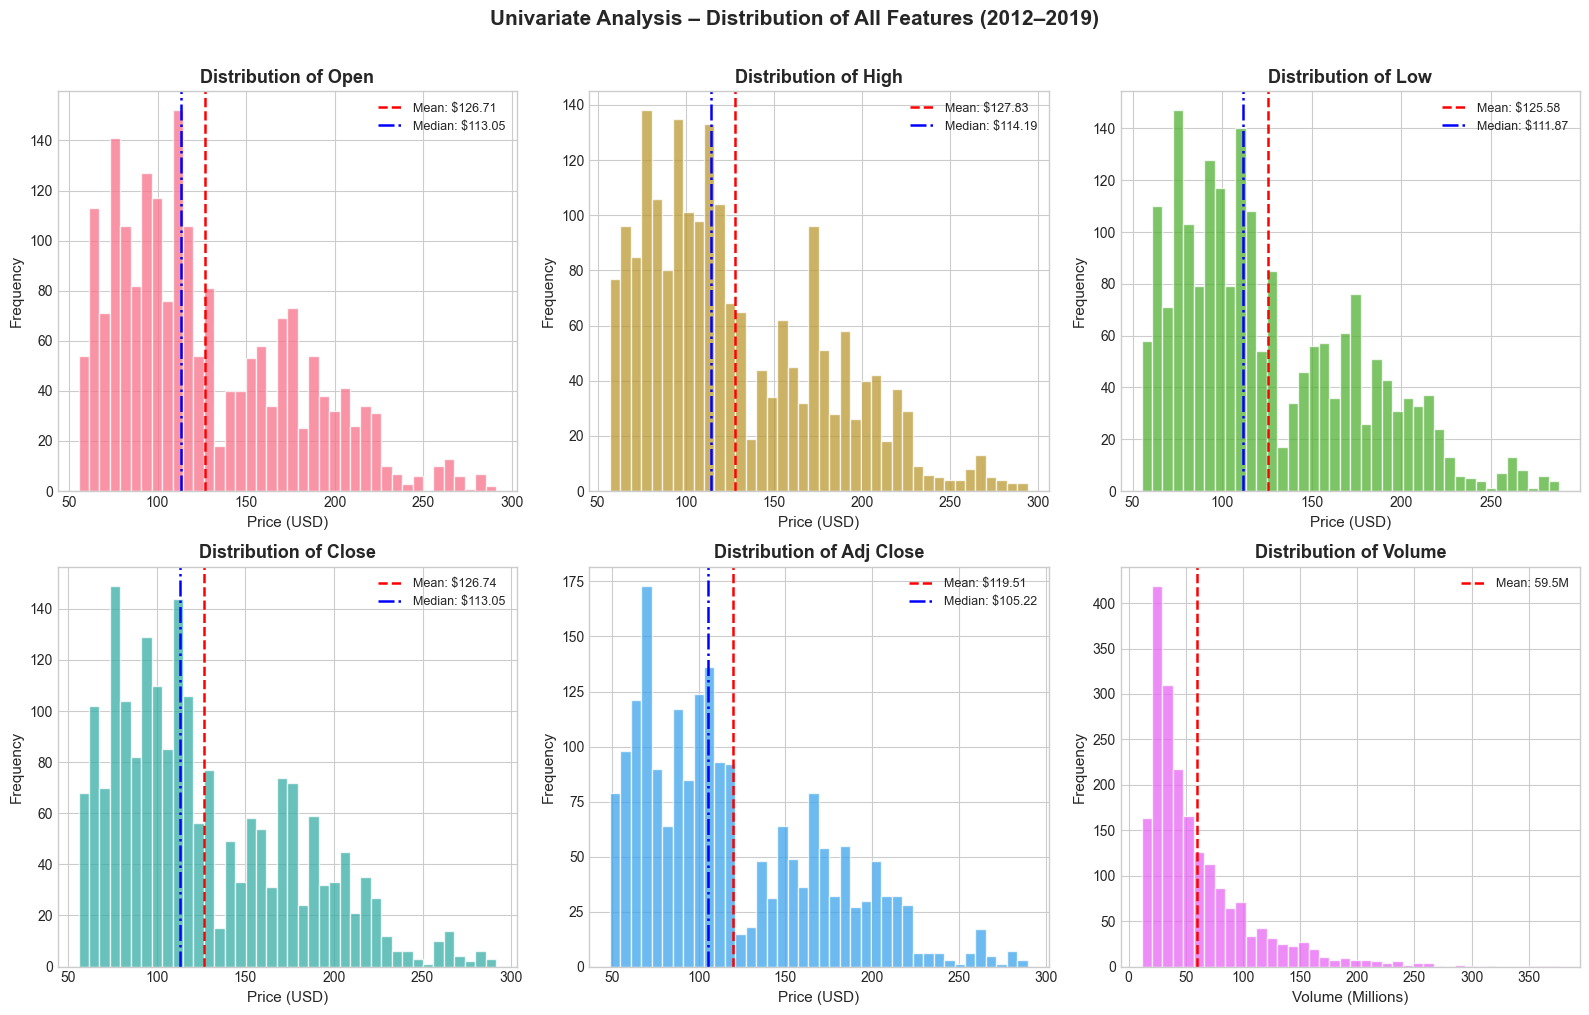

Observation: All price distributions show right skewness, confirming the impact of Apple's strong price growth in the later years.


In [37]:
# Histograms for all features
price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = sns.color_palette('husl', 6)

for i, col in enumerate(price_cols):
    axes[i].hist(df[col], bins=40, color=colors[i], alpha=0.75, edgecolor='white')
    axes[i].axvline(df[col].mean(),   color='red',  linestyle='--', lw=1.8,
                    label=f'Mean: ${df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='blue', linestyle='-.', lw=1.8,
                    label=f'Median: ${df[col].median():.2f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Price (USD)', fontsize=11)
    axes[i].set_ylabel('Frequency',   fontsize=11)
    axes[i].legend(fontsize=9)

# Volume histogram
axes[5].hist(df['Volume'] / 1e6, bins=40, color=colors[5], alpha=0.75, edgecolor='white')
axes[5].axvline(df['Volume'].mean() / 1e6, color='red', linestyle='--', lw=1.8,
                label=f"Mean: {df['Volume'].mean()/1e6:.1f}M")
axes[5].set_title('Distribution of Volume', fontsize=13, fontweight='bold')
axes[5].set_xlabel('Volume (Millions)', fontsize=11)
axes[5].set_ylabel('Frequency',         fontsize=11)
axes[5].legend(fontsize=9)

plt.suptitle('Univariate Analysis – Distribution of All Features (2012–2019)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observation: All price distributions show right skewness,'
      ' confirming the impact of Apple\'s strong price growth in the later years.')


### 3a. Outlier Analysis

Outliers highlight **extreme market movements** across price and especially trading volume.
In stock data, these are **meaningful events, not errors**, often driven by news or volatility.
Hence, they were **retained to preserve important market signals**.


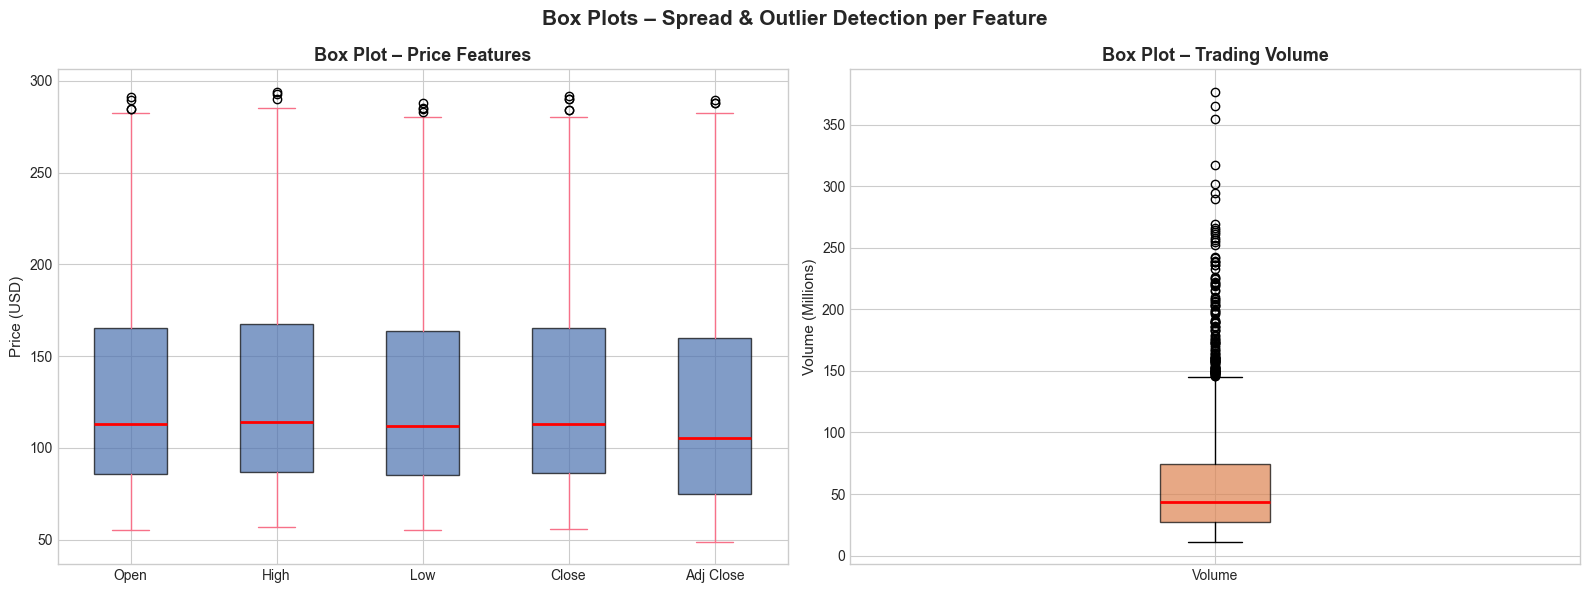

In [38]:
# Box Plots for All Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price features
df[price_cols].plot(kind='box', ax=axes[0], patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Box Plot – Price Features', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=11)

# Volume
axes[1].boxplot(df['Volume'] / 1e6, patch_artist=True,
                boxprops=dict(facecolor='#DD8452', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot – Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume (Millions)', fontsize=11)
axes[1].set_xticklabels(['Volume'])

plt.suptitle('Box Plots – Spread & Outlier Detection per Feature',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 3b. Trend Analysis

Trend analysis reveals the **long-term directional movement** of Apple stock prices
over the 2012–2019 period.

**Why Adj Close?**  
The Adjusted Closing Price accounts for dividends and stock splits, making it the
most accurate measure of Apple's true performance over time.


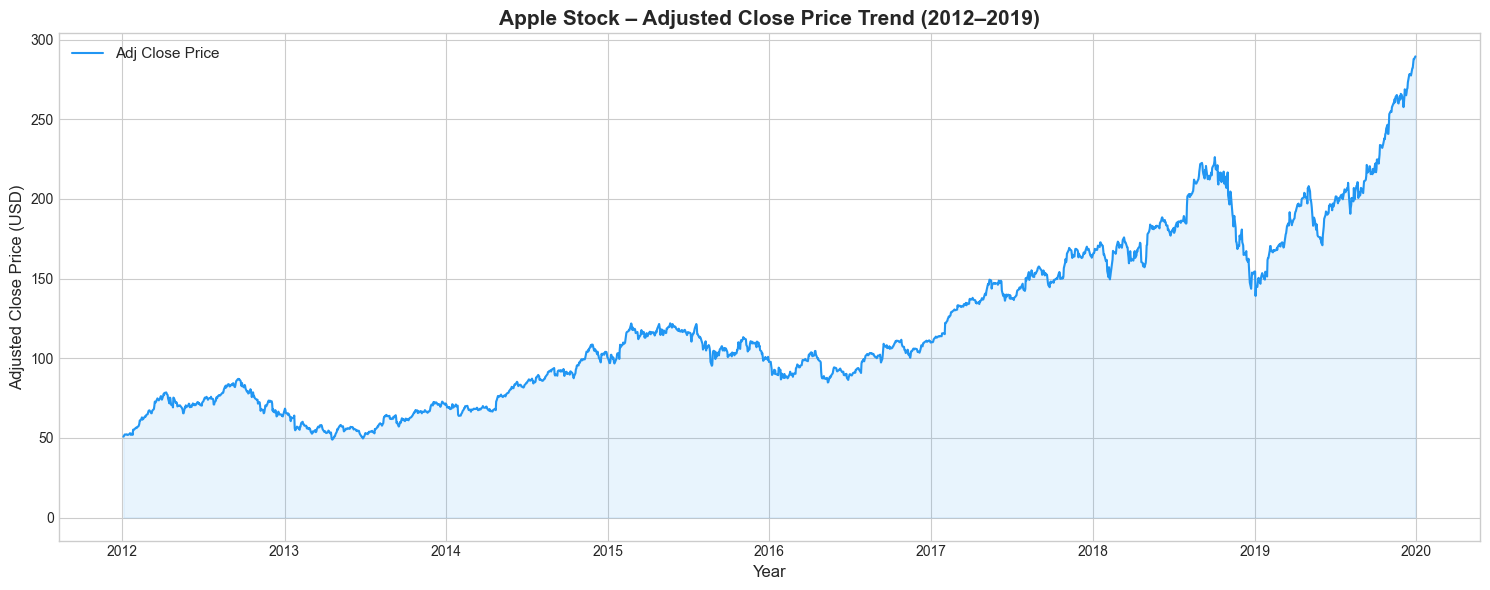

Price Growth Summary:
  Start (Jan 2012): $50.77
  End   (Dec 2019): $289.52
  Total Growth    : 470.3%


In [39]:
# Adjusted Close Price Trend
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df.index, df['Adj Close'], color='#2196F3', linewidth=1.5,
        label='Adj Close Price')
ax.fill_between(df.index, df['Adj Close'], alpha=0.1, color='#2196F3')

ax.set_title('Apple Stock – Adjusted Close Price Trend (2012–2019)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Adjusted Close Price (USD)', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

start_price = df['Adj Close'].iloc[0]
end_price   = df['Adj Close'].iloc[-1]
total_growth = ((end_price - start_price) / start_price) * 100
print(f'Price Growth Summary:')
print(f'  Start (Jan 2012): ${start_price:.2f}')
print(f'  End   (Dec 2019): ${end_price:.2f}')
print(f'  Total Growth    : {total_growth:.1f}%')


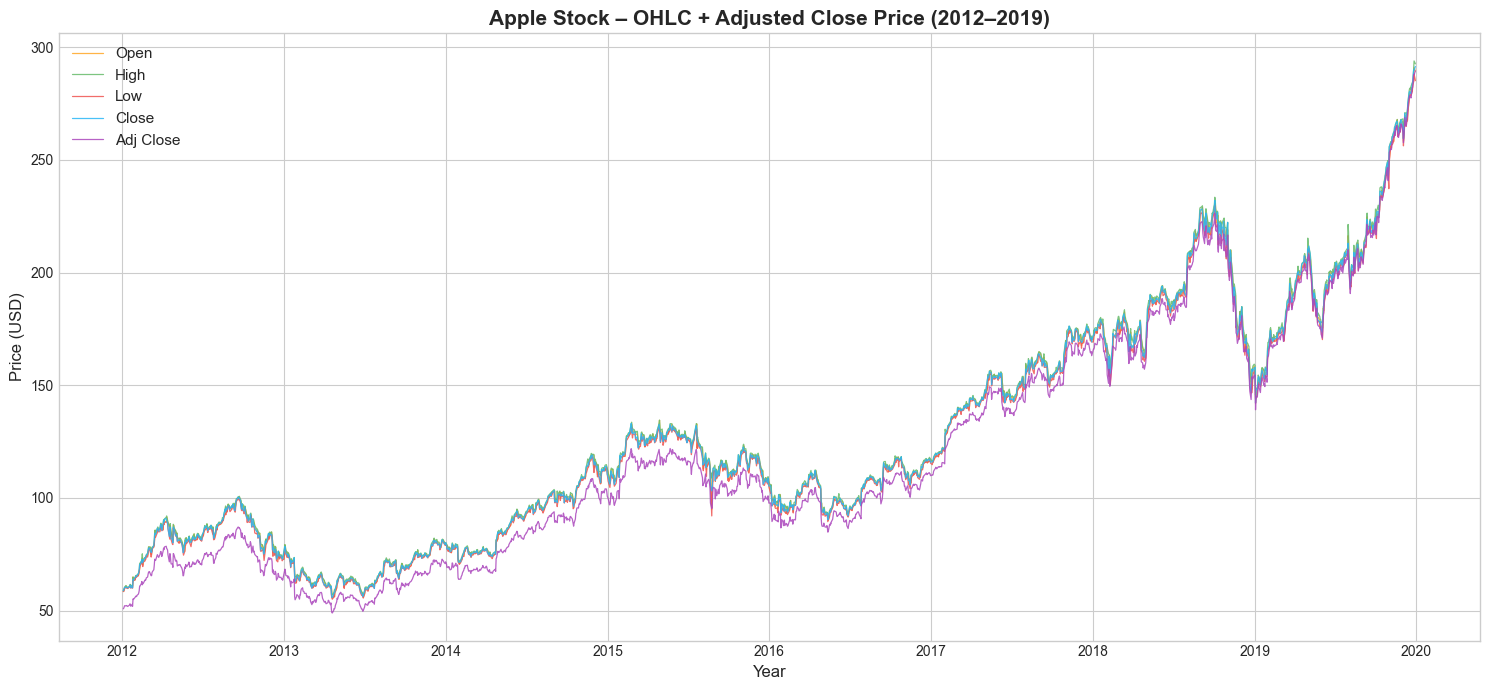

In [40]:
# All OHLC + Adj Close Price Over Time
fig, ax = plt.subplots(figsize=(15, 7))

ohlc_colors = {'Open': '#FFA726', 'High': '#66BB6A',
               'Low':  '#EF5350', 'Close': '#29B6F6', 'Adj Close': '#AB47BC'}

for col, color in ohlc_colors.items():
    ax.plot(df.index, df[col], label=col, color=color, linewidth=0.9, alpha=0.85)

ax.set_title('Apple Stock – OHLC + Adjusted Close Price (2012–2019)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Year',             fontsize=12)
ax.set_ylabel('Price (USD)',      fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()


### 3c. Volume Analysis

Trading volume tells us **how actively the stock is being traded**.
Volume spikes often coincide with:
- Earnings announcements
- Product launches (iPhone releases)
- Major market events or stock splits


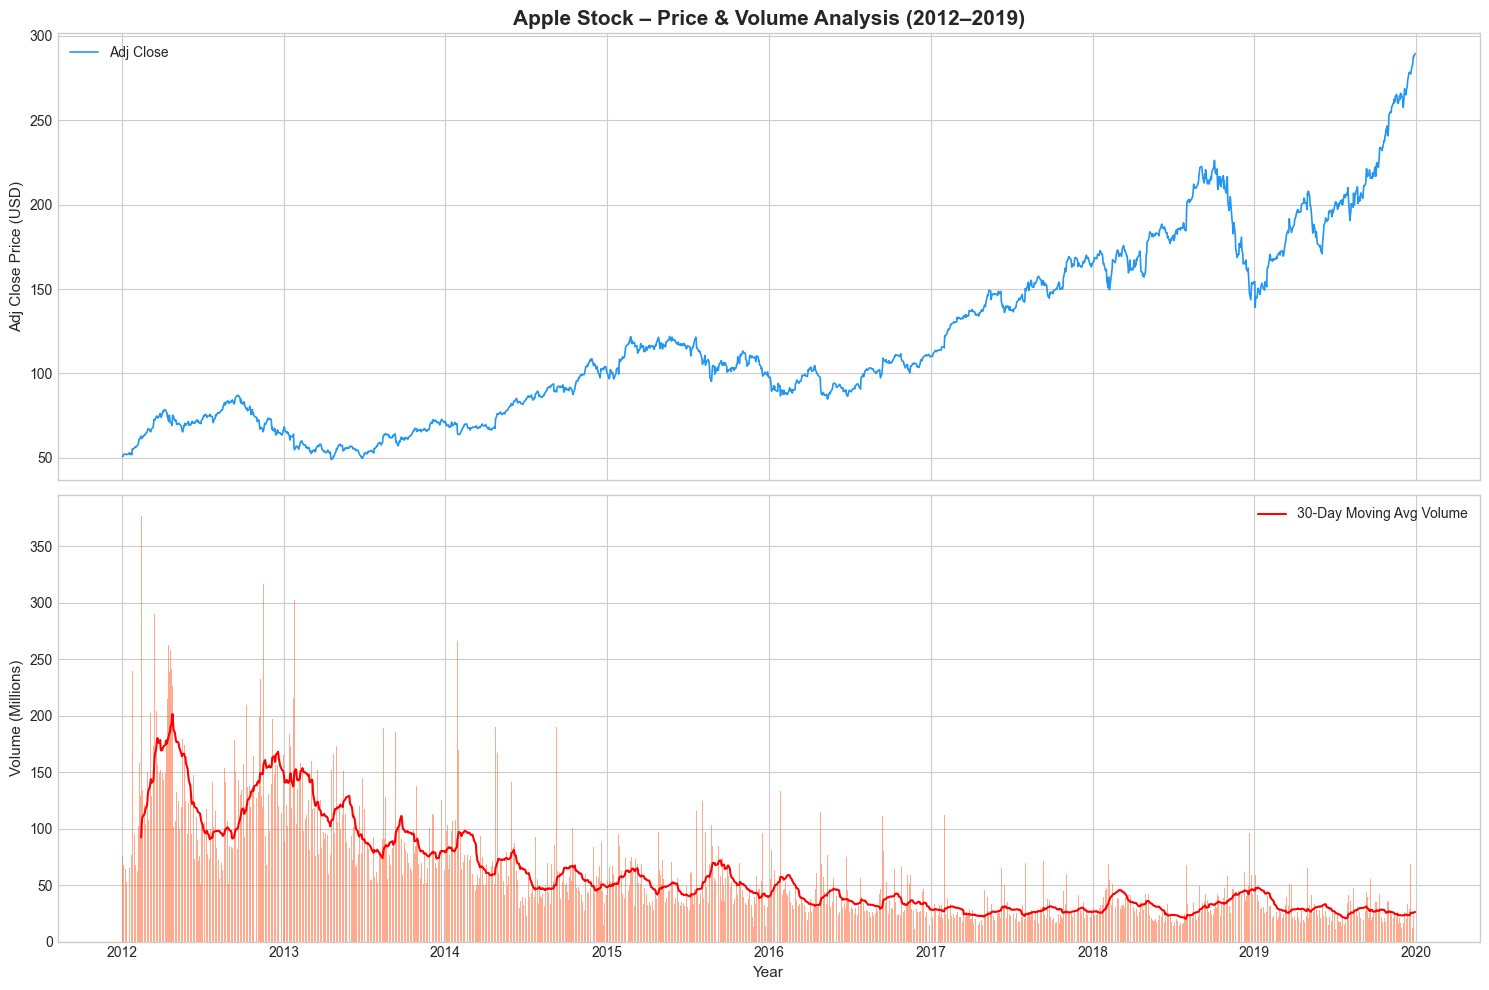

Volume Statistics:
  Mean Volume  : 59.50M shares/day
  Max Volume   : 376.53M shares/day  on 2012-02-15
  Min Volume   : 11.36M shares/day


In [41]:
# Daily Trading Volume Over Time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Adj Close price
ax1.plot(df.index, df['Adj Close'], color='#2196F3', linewidth=1.2)
ax1.set_title('Apple Stock – Price & Volume Analysis (2012–2019)',
              fontsize=15, fontweight='bold')
ax1.set_ylabel('Adj Close Price (USD)', fontsize=11)
ax1.legend(['Adj Close'], loc='upper left', fontsize=10)

# Volume bars + 30-day rolling mean
ax2.bar(df.index, df['Volume'] / 1e6, color='#FF7043', alpha=0.6, width=1)
rolling_vol = df['Volume'].rolling(30).mean() / 1e6
ax2.plot(df.index, rolling_vol, color='red', linewidth=1.5,
         label='30-Day Moving Avg Volume')
ax2.set_xlabel('Year',                fontsize=11)
ax2.set_ylabel('Volume (Millions)',   fontsize=11)
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print('Volume Statistics:')
print(f"  Mean Volume  : {df['Volume'].mean()/1e6:.2f}M shares/day")
print(f"  Max Volume   : {df['Volume'].max()/1e6:.2f}M shares/day  on {df['Volume'].idxmax().date()}")
print(f"  Min Volume   : {df['Volume'].min()/1e6:.2f}M shares/day")


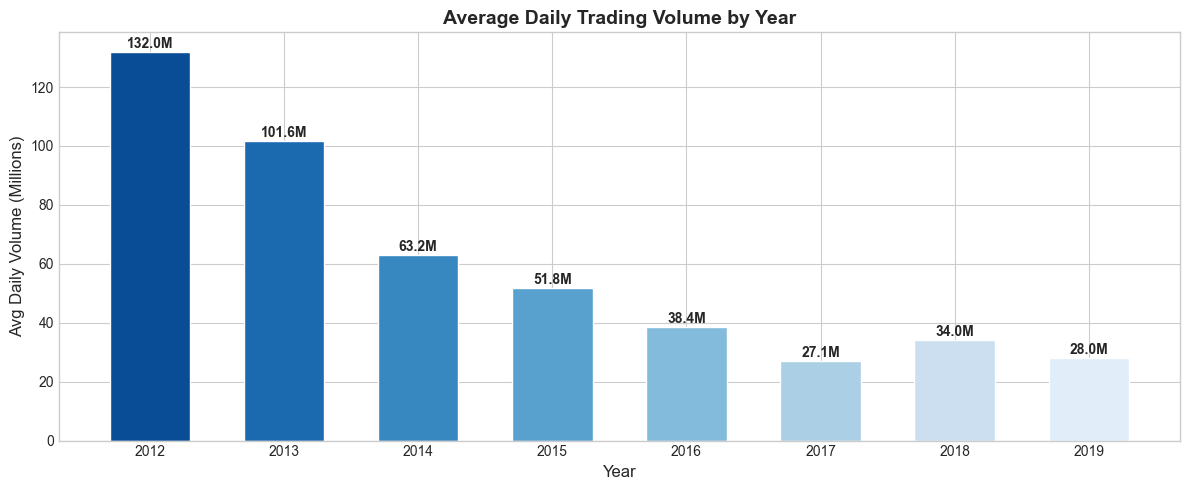

In [42]:
# Yearly Average Volume Trend
yearly_vol = df['Volume'].resample('YE').mean() / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(yearly_vol.index.year, yearly_vol.values,
              color=sns.color_palette('Blues_r', len(yearly_vol)),
              edgecolor='white', width=0.6)

for bar, val in zip(bars, yearly_vol.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Daily Trading Volume by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year',                   fontsize=12)
ax.set_ylabel('Avg Daily Volume (Millions)', fontsize=12)
ax.set_xticks(yearly_vol.index.year)
plt.tight_layout()
plt.show()


---
## Step 4: Feature Engineering
---

We create new meaningful variables from existing data.

| Feature | Formula | Purpose |
|---------|---------|----------|
| **Daily Return** | `(Close_t - Close_{t-1}) / Close_{t-1}` | Day-over-day % price change |
| **Log Return** | `ln(Close_t / Close_{t-1})` | Normalizes returns; better for modeling |
| **Price Range** | `High - Low` | Intraday volatility indicator |
| **MA_7** | 7-day moving average | Short-term trend |
| **MA_30** | 30-day moving average | Medium-term trend |
| **MA_90** | 90-day moving average | Long-term trend |
| **Volatility_30** | 30-day rolling std of returns | Measures price stability |
| **Volume_MA_30** | 30-day moving avg of volume | Smoothed trading activity |
| **Day_of_Week** | 0=Mon … 4=Fri | Weekday seasonality |
| **Month** | 1–12 | Monthly seasonality |
| **Quarter** | 1–4 | Quarterly seasonality |


In [43]:
# Feature Engineering

# Returns
df['Daily_Return']  = df['Adj Close'].pct_change() * 100
df['Log_Return']    = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# Intraday Price Range
df['Price_Range']   = df['High'] - df['Low']

# Moving Averages
df['MA_7']          = df['Adj Close'].rolling(window=7).mean()
df['MA_30']         = df['Adj Close'].rolling(window=30).mean()
df['MA_90']         = df['Adj Close'].rolling(window=90).mean()

# Rolling Volatility (30-day std of daily returns)
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std()

# Volume Moving Average
df['Volume_MA_30']  = df['Volume'].rolling(window=30).mean()

# Time-based features
df['Day_of_Week']   = df.index.dayofweek   # 0=Monday, 4=Friday
df['Month']         = df.index.month
df['Quarter']       = df.index.quarter
df['Year']          = df.index.year

print('Feature Engineering Complete!')
print(f'DataFrame now has {df.shape[1]} columns.')
print(f'New columns: {list(df.columns)}')


Feature Engineering Complete!
DataFrame now has 18 columns.
New columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'Log_Return', 'Price_Range', 'MA_7', 'MA_30', 'MA_90', 'Volatility_30', 'Volume_MA_30', 'Day_of_Week', 'Month', 'Quarter', 'Year']


In [44]:
# Preview enriched dataset (skip first 90 rows where MAs are NaN)
print('Enriched Dataset Preview:')
df.dropna().head()


Enriched Dataset Preview:


,Open,High,Low,Close,Adj Close,Volume,Daily_Return,...,MA_90,Volatility_30,Volume_MA_30,Day_of_Week,Month,Quarter,Year
Date,,,,,,,,,,,,,,,
2012-05-10,82.0829,82.2686,81.2057,81.5029,70.4298,83300000,0.2354,...,65.7579,2.5815,172237263.3333,3,5,2,2012
2012-05-11,80.7143,82.0671,80.6214,80.9586,69.9595,99886500,-0.6678,...,65.9712,2.5757,170498160.0000,4,5,2,2012
2012-05-14,80.3671,81.0729,79.6571,79.7457,68.9114,88156600,-1.4981,...,66.1698,2.5721,167344730.0000,0,5,2,2012
2012-05-15,80.2071,80.4600,78.8214,79.0243,68.2880,119084000,-0.9047,...,66.3551,2.4934,166327933.3333,1,5,2,2012
2012-05-16,79.1500,79.5557,77.2914,78.0114,67.4127,140224000,-1.2817,...,66.5248,2.4677,164047403.3333,2,5,2,2012


---
## Step 5: Trend & Pattern Analysis
---

### 5a. Why Rolling Statistics

Raw stock prices are **noisy**, fluctuating daily due to news, sentiment, and speculation. Rolling statistics help to:

1. **Smooth short-term noise** to reveal true long-term trends
2. **Identify trend direction changes** (Golden Cross / Death Cross)
3. **Measure volatility** over different time windows

| Signal | Condition | Interpretation |
|--------|-----------|----------------|
| **Golden Cross** | Short MA crosses above Long MA | Bullish – Buy Signal |
| **Death Cross**  | Short MA crosses below Long MA | Bearish – Sell Signal |

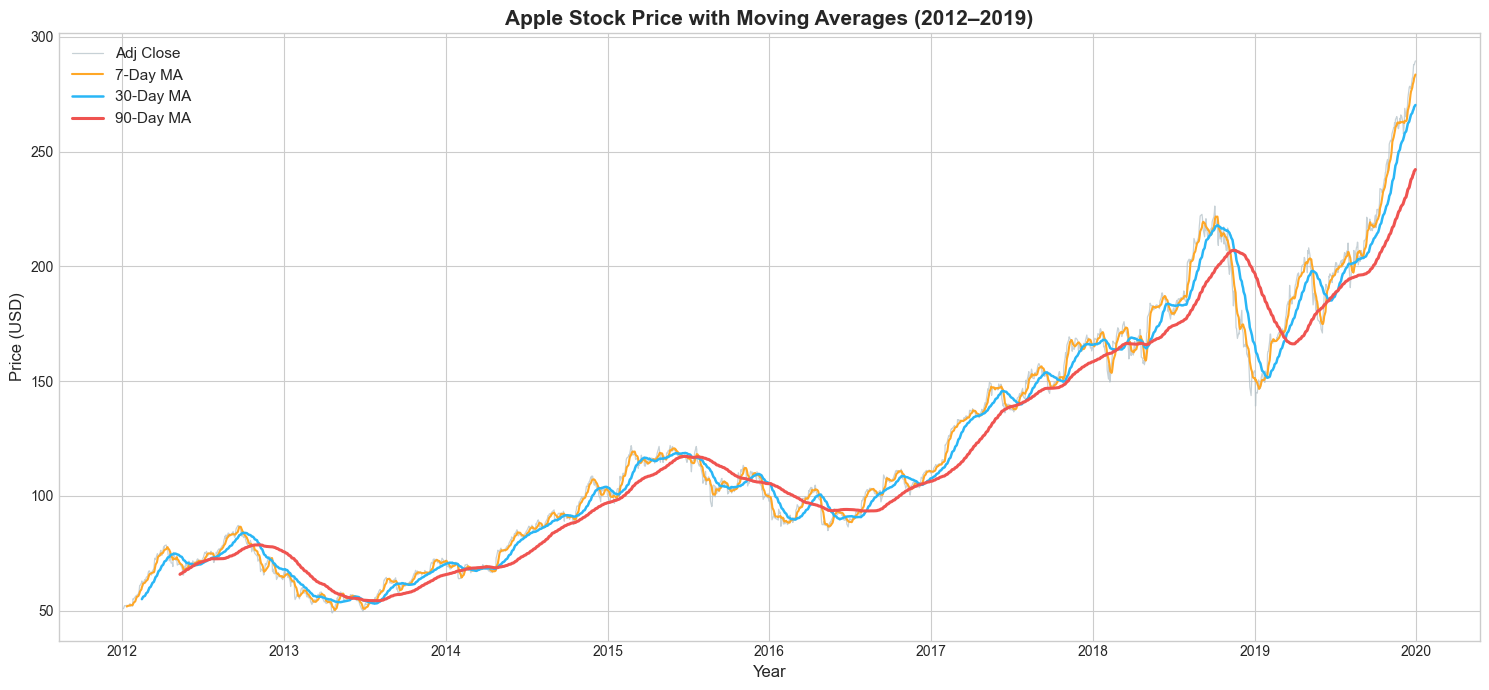

Key Observation:
  - 7-day MA closely tracks daily prices with minimal smoothing
  - 30-day MA filters out weekly volatility
  - 90-day MA reveals the dominant upward trend
  - 2015-2016 correction: Death Cross visible (short MA < long MA)
  - Post-2016 recovery: Golden Cross (short MA crosses back above)


In [45]:
# Moving Averages on Price Chart
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df.index, df['Adj Close'], color='#B0BEC5', linewidth=0.9,
        alpha=0.7, label='Adj Close')
ax.plot(df.index, df['MA_7'],  color='#FFA726', linewidth=1.5, label='7-Day MA')
ax.plot(df.index, df['MA_30'], color='#29B6F6', linewidth=1.8, label='30-Day MA')
ax.plot(df.index, df['MA_90'], color='#EF5350', linewidth=2.2, label='90-Day MA')

ax.set_title('Apple Stock Price with Moving Averages (2012–2019)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Year',            fontsize=12)
ax.set_ylabel('Price (USD)',     fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Key Observation:')
print('  - 7-day MA closely tracks daily prices with minimal smoothing')
print('  - 30-day MA filters out weekly volatility')
print('  - 90-day MA reveals the dominant upward trend')
print('  - 2015-2016 correction: Death Cross visible (short MA < long MA)')
print('  - Post-2016 recovery: Golden Cross (short MA crosses back above)')


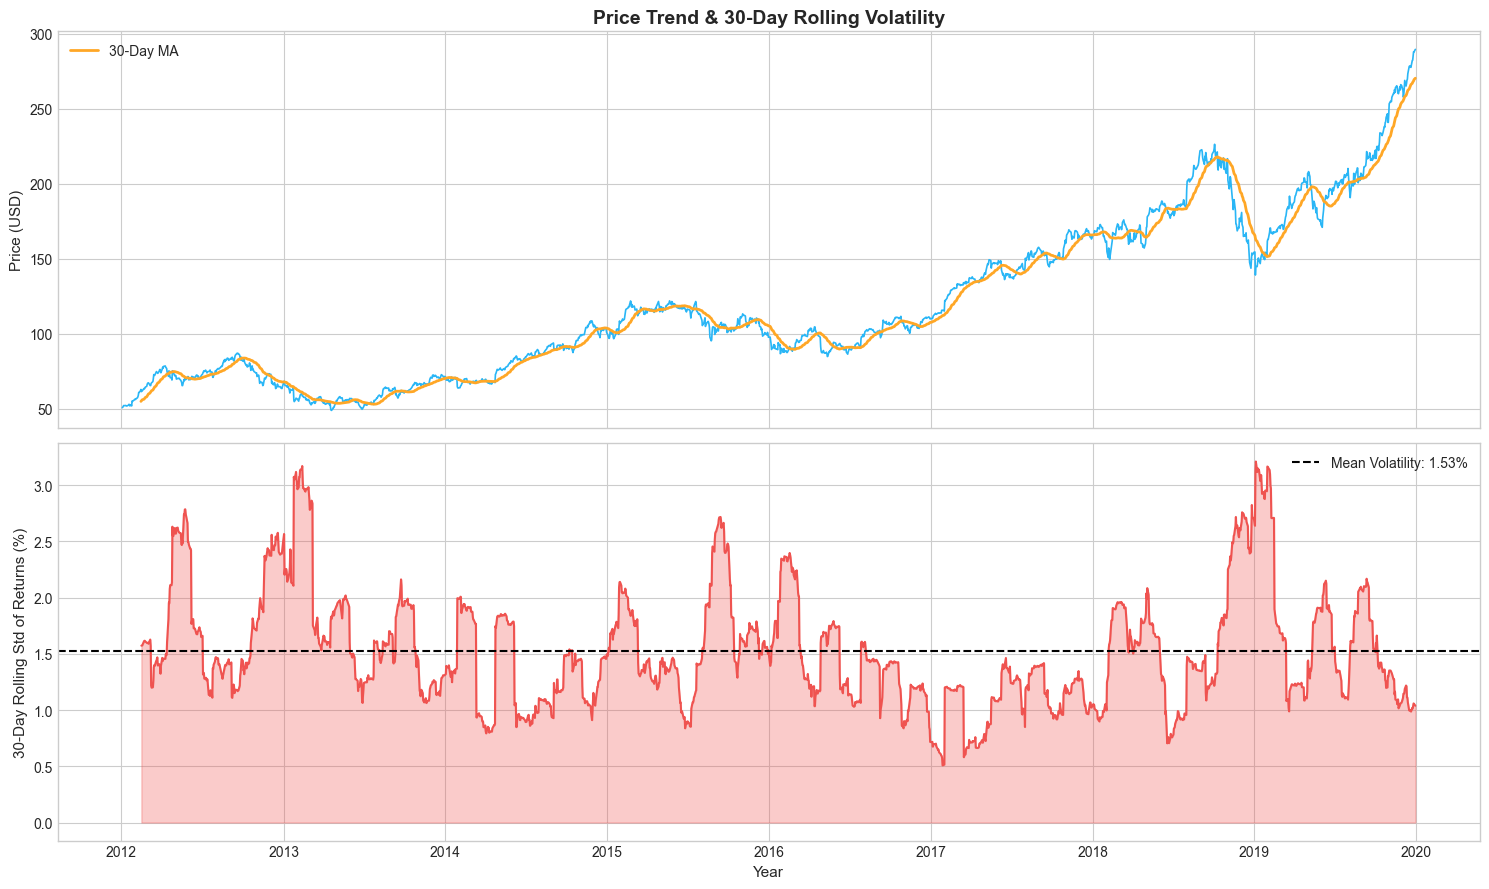

Volatility Statistics:
  Mean 30-Day Volatility : 1.53%
  Max  30-Day Volatility : 3.21%  on 2019-01-04
  Min  30-Day Volatility : 0.51%


In [46]:
# Rolling Volatility (30-Day)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax1.plot(df.index, df['Adj Close'], color='#29B6F6', linewidth=1.2)
ax1.plot(df.index, df['MA_30'],    color='#FFA726', linewidth=2, label='30-Day MA')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(fontsize=10)
ax1.set_title('Price Trend & 30-Day Rolling Volatility', fontsize=14,
              fontweight='bold')

ax2.plot(df.index, df['Volatility_30'], color='#EF5350', linewidth=1.5)
ax2.fill_between(df.index, df['Volatility_30'], alpha=0.3, color='#EF5350')
mean_vol = df['Volatility_30'].mean()
ax2.axhline(mean_vol, color='black', linestyle='--', linewidth=1.5,
            label=f'Mean Volatility: {mean_vol:.2f}%')
ax2.set_xlabel('Year',                                  fontsize=11)
ax2.set_ylabel('30-Day Rolling Std of Returns (%)',    fontsize=11)
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print('Volatility Statistics:')
print(f"  Mean 30-Day Volatility : {df['Volatility_30'].mean():.2f}%")
print(f"  Max  30-Day Volatility : {df['Volatility_30'].max():.2f}%  on {df['Volatility_30'].idxmax().date()}")
print(f"  Min  30-Day Volatility : {df['Volatility_30'].min():.2f}%")


### 5b. Daily Returns Analysis

Daily returns measure the **percentage change in price from one day to the next**.
They are central to quantitative finance because:

- **Stationarity** – Returns are approximately stationary (unlike raw prices)
- **Normality** – Returns roughly follow a normal distribution
- **Risk Measurement** – Volatility = standard deviation of returns
- **Comparability** – Allows comparison across different price ranges


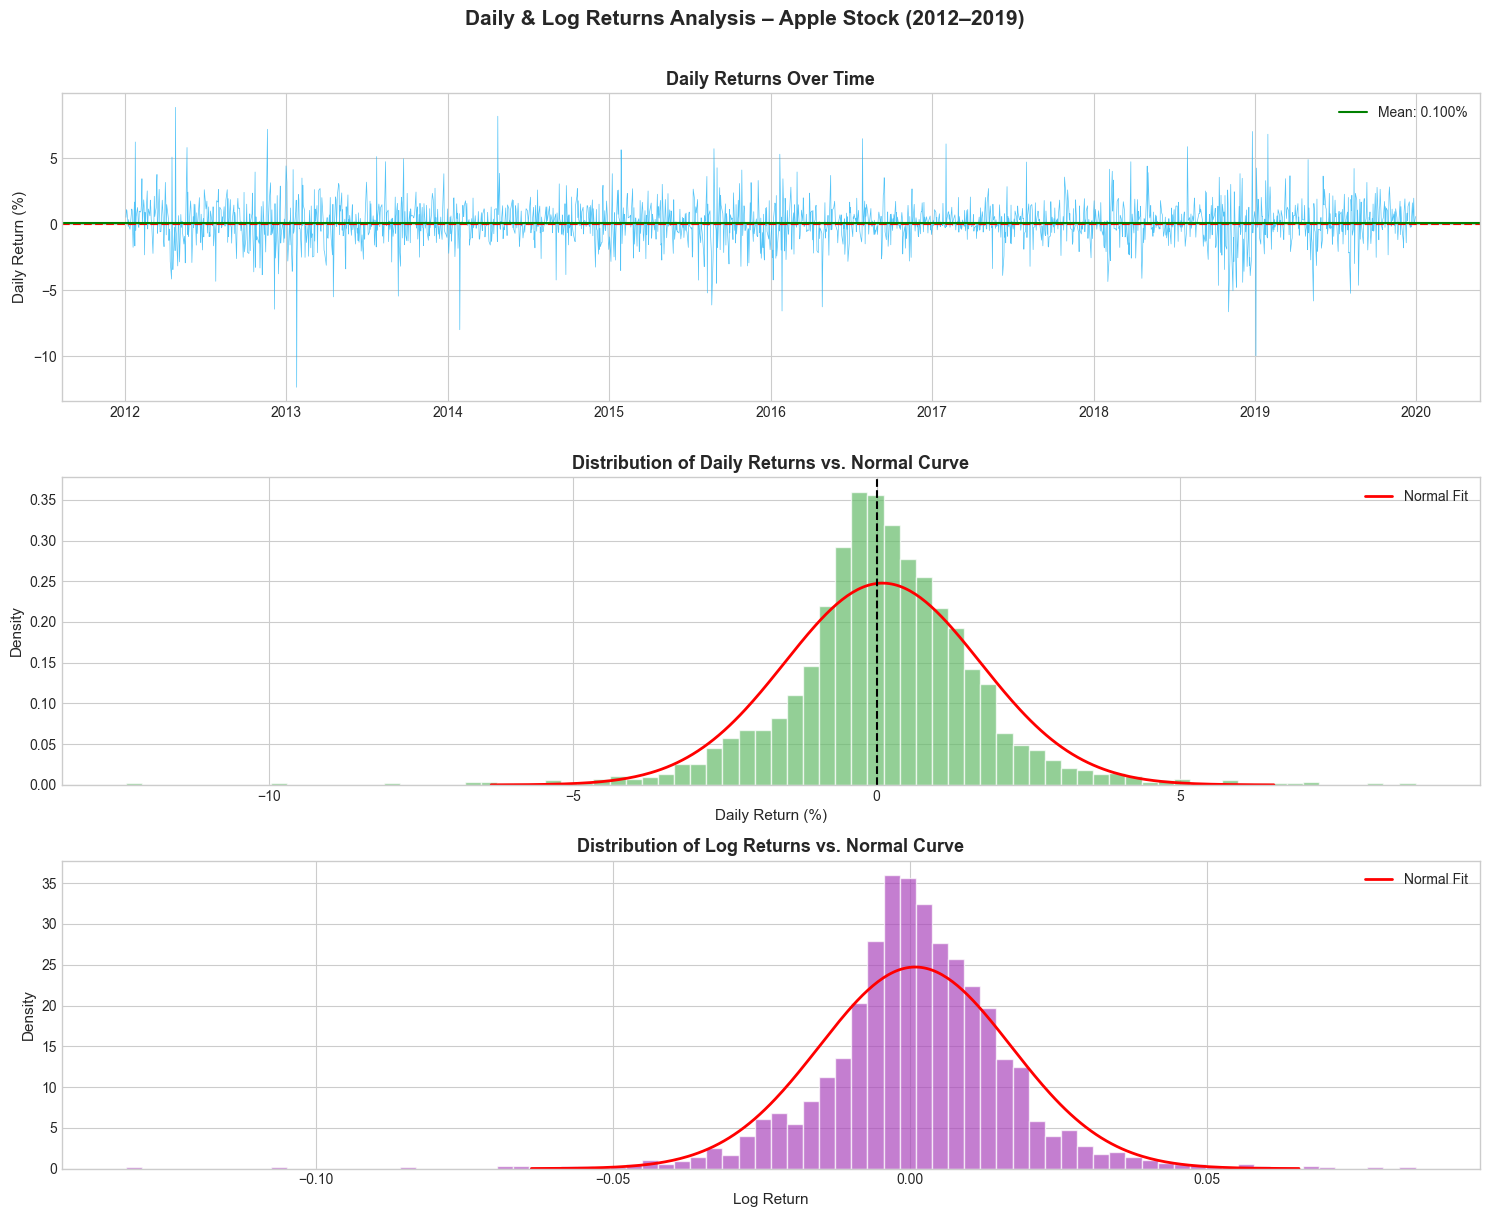

In [47]:
# Daily Returns Time Series & Distribution
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Filter for 2018–2020
#df = df.loc['2018-01-01':'2020-12-31']

# Daily Returns over time
axes[0].plot(df.index, df['Daily_Return'], color='#29B6F6', linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color='red',   linewidth=1.5, linestyle='--')
axes[0].axhline(df['Daily_Return'].mean(), color='green', linewidth=1.5,
                label=f"Mean: {df['Daily_Return'].mean():.3f}%")
axes[0].set_title('Daily Returns Over Time', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Daily Return (%)', fontsize=11)
axes[0].legend(fontsize=10)

# Distribution of daily returns
ret_clean = df['Daily_Return'].dropna()
axes[1].hist(ret_clean, bins=80, color='#66BB6A', edgecolor='white', alpha=0.7, density=True)
mu, sigma = ret_clean.mean(), ret_clean.std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribution of Daily Returns vs. Normal Curve',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)', fontsize=11)
axes[1].set_ylabel('Density',          fontsize=11)
axes[1].legend(fontsize=10)

# Log Returns distribution
log_clean = df['Log_Return'].dropna()
axes[2].hist(log_clean, bins=80, color='#AB47BC', edgecolor='white', alpha=0.7, density=True)
mu_l, sig_l = log_clean.mean(), log_clean.std()
x_l = np.linspace(mu_l - 4*sig_l, mu_l + 4*sig_l, 300)
axes[2].plot(x_l, stats.norm.pdf(x_l, mu_l, sig_l), 'r-', linewidth=2, label='Normal Fit')
axes[2].set_title('Distribution of Log Returns vs. Normal Curve',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Log Return', fontsize=11)
axes[2].set_ylabel('Density',    fontsize=11)
axes[2].legend(fontsize=10)

plt.suptitle('Daily & Log Returns Analysis – Apple Stock (2012–2019)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [48]:
# Returns Statistics Summary
returns = df['Daily_Return'].dropna()

skewness = returns.skew()
kurtosis = returns.kurtosis()

print('=' * 52)
print('         DAILY RETURNS STATISTICS')
print('=' * 52)
print(f'  Mean Return     : {returns.mean():.4f}%')
print(f'  Std Deviation   : {returns.std():.4f}%')
print(f"  Min Return      : {returns.min():.4f}%  on {returns.idxmin().date()}")
print(f"  Max Return      : {returns.max():.4f}%  on {returns.idxmax().date()}")
print(f"  Skewness        : {skewness:.4f} ({'Right-skewed' if skewness > 0 else 'Left-skewed'})")
print(f"  Excess Kurtosis : {kurtosis:.4f} ({'Leptokurtic - fat tails' if kurtosis > 0 else 'Platykurtic'})")
print('=' * 52)
print()
print('Insight: Excess kurtosis > 0 (leptokurtic) confirms that extreme returns')
print('occur more often than a pure normal distribution would predict.')
print('This fat-tail behavior is a hallmark of financial time series.')


         DAILY RETURNS STATISTICS
  Mean Return     : 0.0997%
  Std Deviation   : 1.6107%
  Min Return      : -12.3558%  on 2013-01-24
  Max Return      : 8.8741%  on 2012-04-25
  Skewness        : -0.2538 (Left-skewed)
  Excess Kurtosis : 5.2011 (Leptokurtic - fat tails)

Insight: Excess kurtosis > 0 (leptokurtic) confirms that extreme returns
occur more often than a pure normal distribution would predict.
This fat-tail behavior is a hallmark of financial time series.


### 5c. Seasonality Analysis

Apple stock tends to exhibit recurring patterns tied to:
- **Earnings releases** (Jan, Apr, Jul, Oct)
- **iPhone launch seasons** (typically September–October)
- **Year-end portfolio rebalancing** (December)

| Level | Period | What It Reveals |
|-------|--------|-----------------|
| Day of Week | Mon–Fri | Weekday effect on returns |
| Monthly | Jan–Dec | Best/worst months to hold |
| Quarterly | Q1–Q4 | Earnings-driven patterns |
| Yearly | 2012–2019 | Multi-year growth trend |


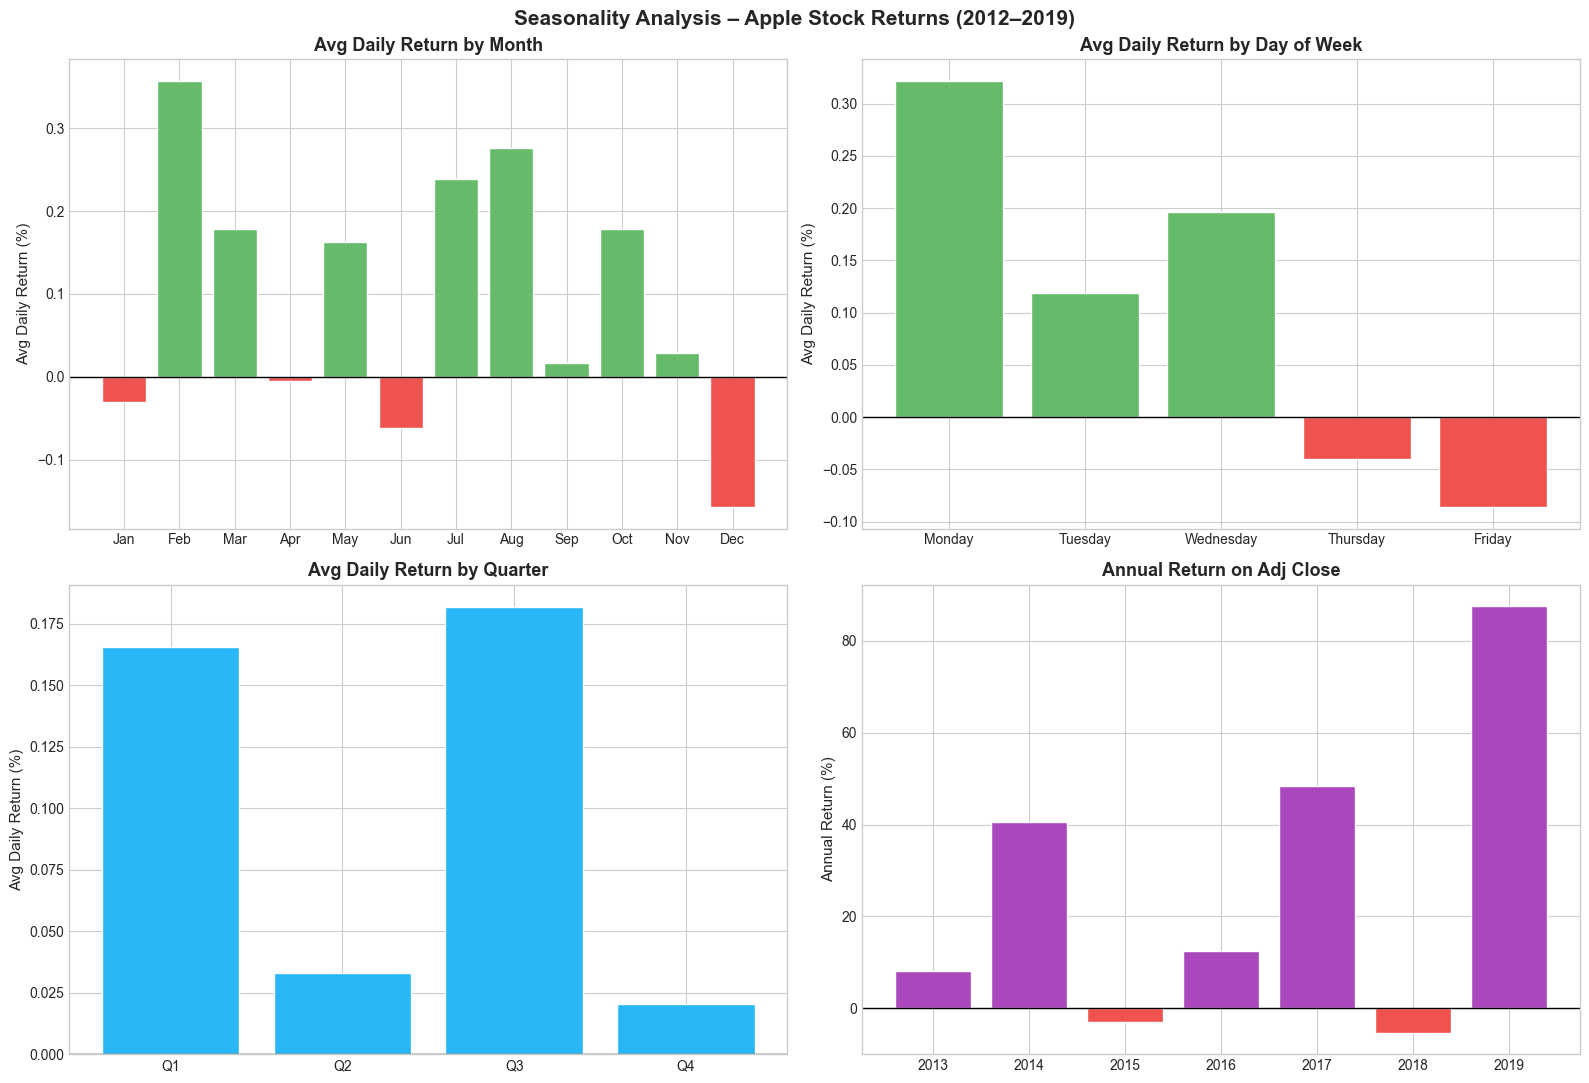

In [49]:
# Seasonality Charts
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly average returns
monthly_returns = df['Daily_Return'].groupby(df.index.month).mean()
colors_m = ['#EF5350' if v < 0 else '#66BB6A' for v in monthly_returns.values]
axes[0, 0].bar(month_names, monthly_returns.values, color=colors_m, edgecolor='white')
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title('Avg Daily Return by Month',     fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Avg Daily Return (%)',          fontsize=11)

# Day-of-week returns
dow_returns = df['Daily_Return'].groupby(df.index.dayofweek).mean()
day_names   = ['Monday','Tuesday','Wednesday','Thursday','Friday']
colors_d = ['#EF5350' if v < 0 else '#66BB6A' for v in dow_returns.values]
axes[0, 1].bar(day_names, dow_returns.values, color=colors_d, edgecolor='white')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Avg Daily Return by Day of Week', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Avg Daily Return (%)',            fontsize=11)

# Quarterly returns
quarterly_returns = df['Daily_Return'].groupby(df.index.quarter).mean()
colors_q = ['#EF5350' if v < 0 else '#29B6F6' for v in quarterly_returns.values]
axes[1, 0].bar(['Q1','Q2','Q3','Q4'], quarterly_returns.values,
               color=colors_q, edgecolor='white')
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title('Avg Daily Return by Quarter', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Avg Daily Return (%)',        fontsize=11)

# Yearly performance (annual return)
yearly_adj = df['Adj Close'].resample('YE').last()
yearly_ret = yearly_adj.pct_change() * 100
yr_colors  = ['#EF5350' if v < 0 else '#AB47BC' for v in yearly_ret.values[1:]]
axes[1, 1].bar(yearly_adj.index.year[1:], yearly_ret.values[1:],
               color=yr_colors, edgecolor='white')
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Annual Return on Adj Close', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Annual Return (%)',          fontsize=11)

plt.suptitle('Seasonality Analysis – Apple Stock Returns (2012–2019)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 6: Correlation Analysis
---

### Why Correlation Matters for Forecasting

1. **Identify redundant features** – Highly correlated features → keep only one
2. **Understand the feature space** – See the structure of our data
3. **Select predictors** – Choose features most correlated with the target

### How to Read a Correlation Heatmap
- **Close to +1 (Dark Red)** → Strong positive relationship
- **Close to -1 (Dark Blue)** → Strong negative relationship
- **Near 0 (White/Light)** → Little to no relationship


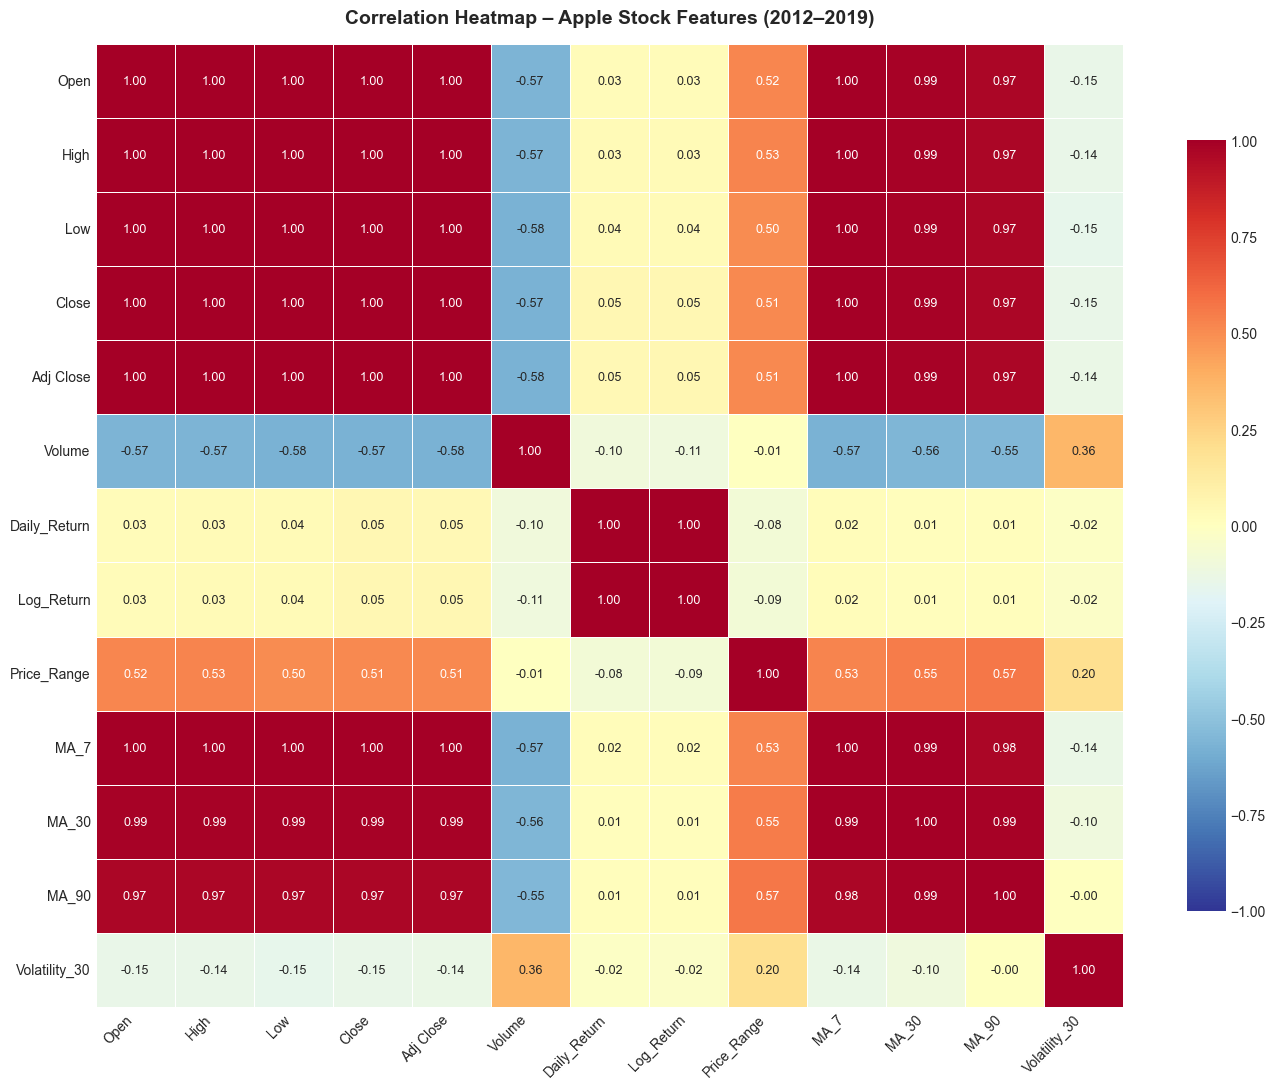

In [50]:
# Correlation Heatmap
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
             'Daily_Return', 'Log_Return', 'Price_Range',
             'MA_7', 'MA_30', 'MA_90', 'Volatility_30']

corr_df = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_df,
            annot=True, fmt='.2f',
            cmap='RdYlBu_r',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

ax.set_title('Correlation Heatmap – Apple Stock Features (2012–2019)',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0,              fontsize=10)
plt.tight_layout()
plt.show()


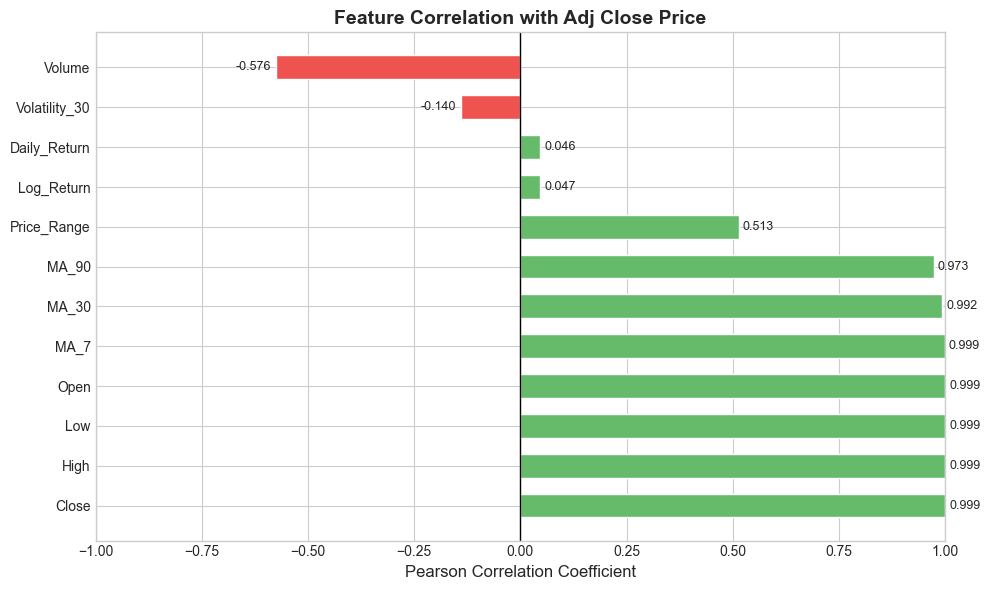

Correlation Insights:
  Open, High, Low, Close : Near-perfect correlation (>0.99) with Adj Close
  Moving Averages        : Very high correlation — useful predictors
  Volume                 : Weak/negative correlation — independent information
  Daily/Log Returns      : Near-zero correlation with price level
                           (returns are stationary; prices are not)


In [51]:
# Top Correlations with Adjusted Close Price
corr_with_target = corr_df['Adj Close'].drop('Adj Close').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = ['#EF5350' if v < 0 else '#66BB6A' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors_corr, edgecolor='white', height=0.6)

for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha=('left' if val >= 0 else 'right'), fontsize=9)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-1, 1)
ax.set_title('Feature Correlation with Adj Close Price',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.tight_layout()
plt.show()

print('Correlation Insights:')
print('  Open, High, Low, Close : Near-perfect correlation (>0.99) with Adj Close')
print('  Moving Averages        : Very high correlation — useful predictors')
print('  Volume                 : Weak/negative correlation — independent information')
print('  Daily/Log Returns      : Near-zero correlation with price level')
print('                           (returns are stationary; prices are not)')


---
## Step 7: Statistical Preprocessing
---

### 7a. Outlier Handling

**Z-Score Based Outlier Detection on Daily Returns**

A daily return is flagged as an outlier if |Z-score| > 3
(more than 3 standard deviations from the mean).

Stock market outliers are commonly caused by:
- Earnings surprises
- Major product announcements
- Market crashes or corrections
- Macro-economic shocks

In [52]:
# Z-Score Outlier Detection on Daily Returns
returns_clean = df['Daily_Return'].dropna()
z_scores      = np.abs(stats.zscore(returns_clean))
outlier_mask  = z_scores > 3

outlier_dates = returns_clean[outlier_mask].sort_values(key=abs, ascending=False)

print(f'Total Trading Days Analyzed       : {len(returns_clean)}')
print(f'Outlier Days Detected (|Z| > 3)   : {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}% of days)')
print()
print('Top 10 Extreme Return Days:')
print('-' * 50)
for date, ret in outlier_dates.head(10).items():
    direction = 'UP  ' if ret > 0 else 'DOWN'
    print(f'  [{direction}] {date.date()}  |  Return: {ret:+.2f}%')


Total Trading Days Analyzed       : 2010
Outlier Days Detected (|Z| > 3)   : 31 (1.54% of days)

Top 10 Extreme Return Days:
--------------------------------------------------
  [DOWN] 2013-01-24  |  Return: -12.36%
  [DOWN] 2019-01-03  |  Return: -9.96%
  [UP  ] 2012-04-25  |  Return: +8.87%
  [UP  ] 2014-04-24  |  Return: +8.20%
  [DOWN] 2014-01-28  |  Return: -7.99%
  [UP  ] 2012-11-19  |  Return: +7.21%
  [UP  ] 2018-12-26  |  Return: +7.04%
  [UP  ] 2019-01-30  |  Return: +6.83%
  [DOWN] 2018-11-02  |  Return: -6.63%
  [DOWN] 2016-01-27  |  Return: -6.57%


### 7b. Stationarity Test (ADF Test)

**What is Stationarity?**

A time series is **stationary** if its statistical properties (mean, variance,
covariance) do not change over time.

### Augmented Dickey-Fuller (ADF) Test

| Hypothesis | Meaning |
|-----------|----------|
| **H₀ (Null)** | Series has a unit root → Non-stationary |
| **H₁ (Alt)** | Series is stationary |

**Decision Rule:** If p-value < 0.05 → Reject H₀ → Series is Stationary


In [53]:
# ADF Test on multiple series
def run_adf_test(series, series_name):
    clean  = series.dropna()
    result = adfuller(clean, autolag='AIC')
    print(f"\n{'='*55}")
    print(f"  ADF Test: {series_name}")
    print(f"{'='*55}")
    print(f"  ADF Statistic : {result[0]:.6f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Lags Used     : {result[2]}")
    print(f"  Obs Used      : {result[3]}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"      {key}: {val:.6f}")
    if result[1] < 0.05:
        print('  RESULT: STATIONARY (p < 0.05 => Reject H0)')
    else:
        print('  RESULT: NON-STATIONARY (p >= 0.05 => Fail to Reject H0)')
    print(f"{'='*55}")

run_adf_test(df['Adj Close'],    'Adj Close Price (Raw)')
run_adf_test(df['Daily_Return'], 'Daily Returns')
run_adf_test(df['Log_Return'],   'Log Returns')

df['Close_Diff'] = df['Adj Close'].diff()
run_adf_test(df['Close_Diff'],   'First-Differenced Adj Close')



  ADF Test: Adj Close Price (Raw)
  ADF Statistic : 1.453800
  p-value       : 0.997345
  Lags Used     : 9
  Obs Used      : 2001
  Critical Values:
      1%: -3.433622
      5%: -2.862985
      10%: -2.567540
  RESULT: NON-STATIONARY (p >= 0.05 => Fail to Reject H0)

  ADF Test: Daily Returns
  ADF Statistic : -15.805167
  p-value       : 0.000000
  Lags Used     : 7
  Obs Used      : 2002
  Critical Values:
      1%: -3.433621
      5%: -2.862985
      10%: -2.567539
  RESULT: STATIONARY (p < 0.05 => Reject H0)

  ADF Test: Log Returns
  ADF Statistic : -15.710245
  p-value       : 0.000000
  Lags Used     : 7
  Obs Used      : 2002
  Critical Values:
      1%: -3.433621
      5%: -2.862985
      10%: -2.567539
  RESULT: STATIONARY (p < 0.05 => Reject H0)

  ADF Test: First-Differenced Adj Close
  ADF Statistic : -13.472641
  p-value       : 0.000000
  Lags Used     : 8
  Obs Used      : 2001
  Critical Values:
      1%: -3.433622
      5%: -2.862985
      10%: -2.567540
  RESULT: 

---
## Step 8: Key Insights & Summary
---


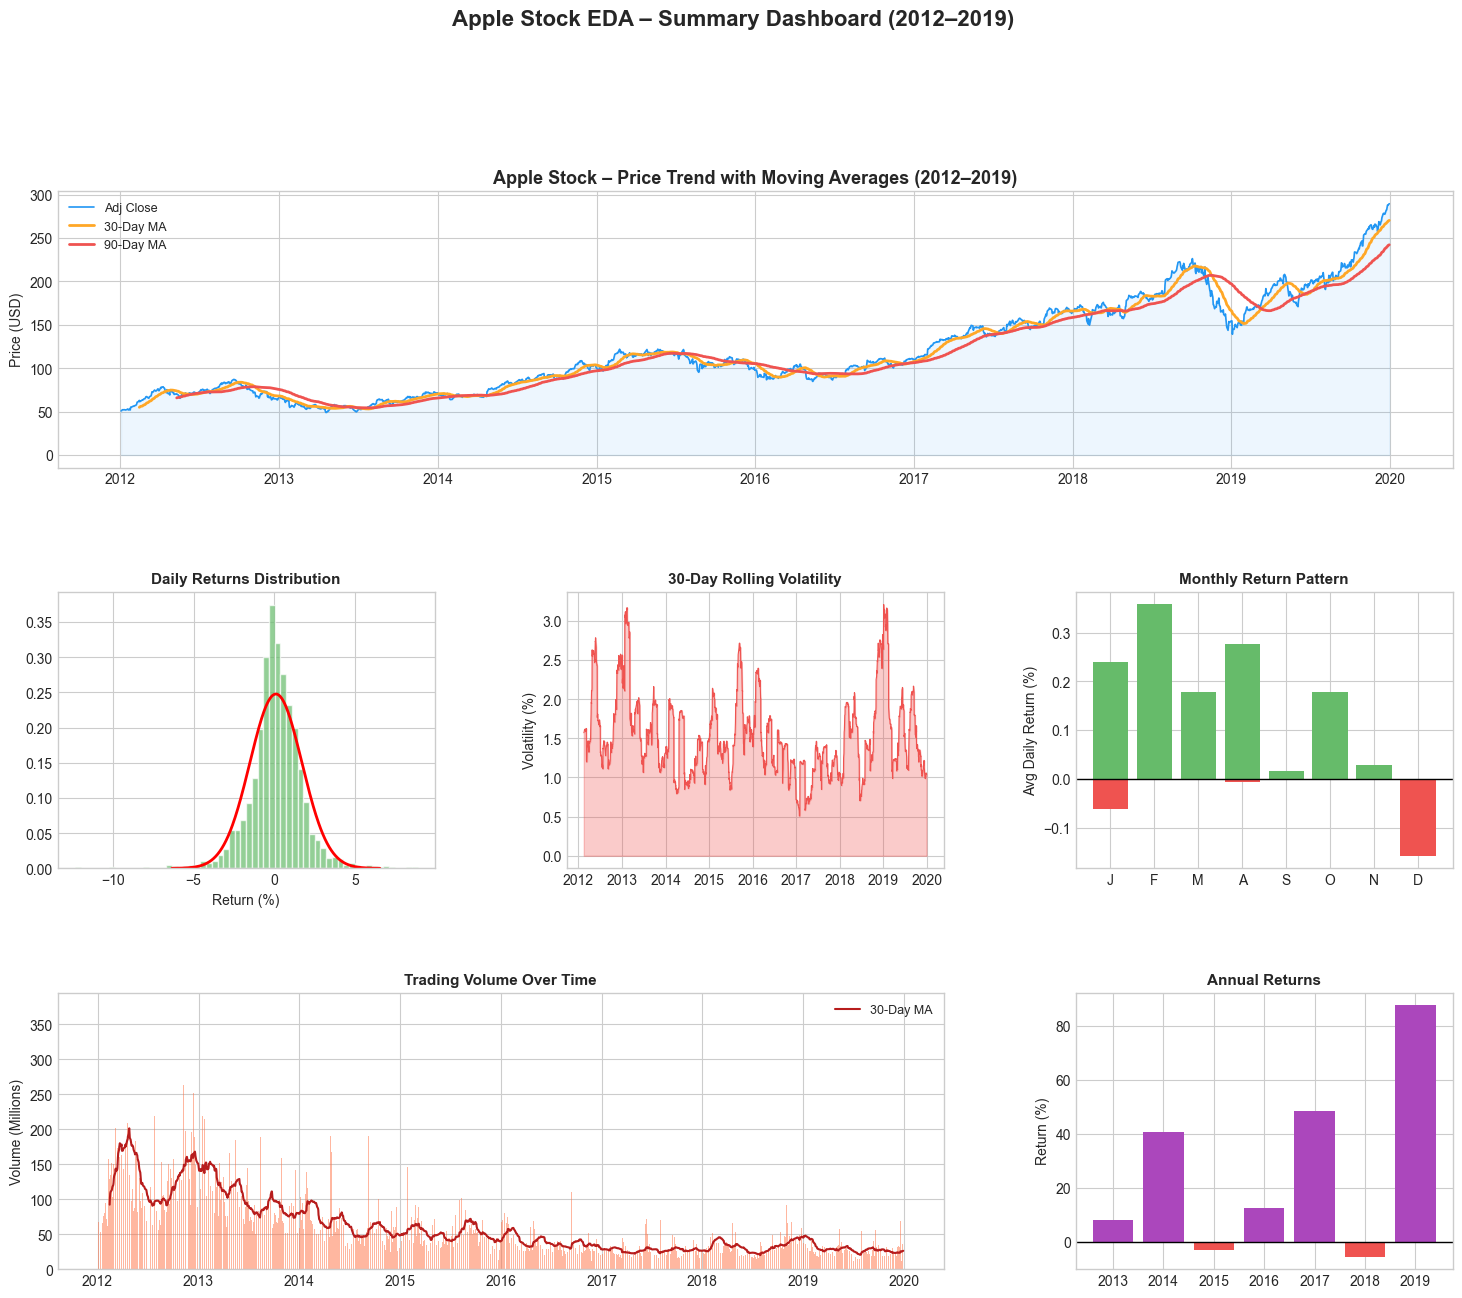

Summary dashboard saved as Apple_EDA_Summary_Dashboard.png


In [54]:
# Final Summary Dashboard
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)
os.makedirs('results', exist_ok=True)

# 1. Price Trend with MAs
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['Adj Close'], color='#2196F3', lw=1.2, label='Adj Close')
ax1.plot(df.index, df['MA_30'],     color='#FFA726', lw=2.0, label='30-Day MA')
ax1.plot(df.index, df['MA_90'],     color='#EF5350', lw=2.0, label='90-Day MA')
ax1.fill_between(df.index, df['Adj Close'], alpha=0.08, color='#2196F3')
ax1.set_title('Apple Stock – Price Trend with Moving Averages (2012–2019)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. Returns Distribution
ax2 = fig.add_subplot(gs[1, 0])
ret_d = df['Daily_Return'].dropna()
ax2.hist(ret_d, bins=60, color='#66BB6A', edgecolor='white', alpha=0.7, density=True)
mu_d, sg_d = ret_d.mean(), ret_d.std()
xd = np.linspace(mu_d - 4*sg_d, mu_d + 4*sg_d, 300)
ax2.plot(xd, stats.norm.pdf(xd, mu_d, sg_d), 'r-', lw=2)
ax2.set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('Return (%)')

# 3. Volatility
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df.index, df['Volatility_30'], color='#EF5350', lw=0.8)
ax3.fill_between(df.index, df['Volatility_30'], alpha=0.3, color='#EF5350')
ax3.set_title('30-Day Rolling Volatility', fontsize=11, fontweight='bold')
ax3.set_ylabel('Volatility (%)')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 4. Monthly Seasonality
ax4 = fig.add_subplot(gs[1, 2])
mo_ret  = df['Daily_Return'].groupby(df.index.month).mean()
mo_names = ['J','F','M','A','M','J','J','A','S','O','N','D']
cols_m = ['#EF5350' if v < 0 else '#66BB6A' for v in mo_ret.values]
ax4.bar(mo_names, mo_ret.values, color=cols_m)
ax4.axhline(0, color='black', lw=1)
ax4.set_title('Monthly Return Pattern', fontsize=11, fontweight='bold')
ax4.set_ylabel('Avg Daily Return (%)')

# 5. Volume Trend
ax5 = fig.add_subplot(gs[2, :2])
ax5.bar(df.index, df['Volume']/1e6, color='#FF7043', alpha=0.5, width=1)
ax5.plot(df.index, df['Volume_MA_30']/1e6, color='#B71C1C', lw=1.5, label='30-Day MA')
ax5.set_title('Trading Volume Over Time', fontsize=11, fontweight='bold')
ax5.set_ylabel('Volume (Millions)')
ax5.legend(fontsize=9)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 6. Yearly Performance
ax6 = fig.add_subplot(gs[2, 2])
y_adj = df['Adj Close'].resample('YE').last()
y_ret = y_adj.pct_change().dropna() * 100
y_col = ['#EF5350' if v < 0 else '#AB47BC' for v in y_ret.values]
ax6.bar(y_ret.index.year, y_ret.values, color=y_col)
ax6.axhline(0, color='black', lw=1)
ax6.set_title('Annual Returns', fontsize=11, fontweight='bold')
ax6.set_ylabel('Return (%)')

plt.suptitle('Apple Stock EDA – Summary Dashboard (2012–2019)',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('results/Apple_EDA_Summary_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary dashboard saved as Apple_EDA_Summary_Dashboard.png')


In [55]:
# Save the modeling-ready dataset
df.to_csv('stock_predict.csv', index=False)
print("Saved 'stock_predict.csv' — ready for Model Building!")

Saved 'stock_predict.csv' — ready for Model Building!
